# Categorical Model 

In the previous model, we treated all columns as numerical columns. However, some columns make more sense when interpreted as categorical features.

In [1]:
import pandas as pd
import numpy as np

## Reexamine the data 


In [7]:
DATA_PATH = "train_test_network.csv"
df = pd.read_csv(DATA_PATH)

rows = len(df)

print(f"Rows: {rows}")

Rows: 211043


### Counting columns with "-" placeholders

In [4]:
dash_counts = (df.astype(str) == "-").sum().sort_values(ascending=False)

dash_counts[dash_counts > 0]

ssl_subject             211032
ssl_issuer              211032
http_orig_mime_types    211027
weird_addl              210886
http_resp_mime_types    210839
http_uri                210756
http_user_agent         210756
http_method             210756
http_version            210745
http_trans_depth        210740
weird_notice            210687
weird_name              210687
ssl_cipher              210642
ssl_version             210642
ssl_resumed             210642
ssl_established         210642
dns_query               176198
dns_AA                  176030
dns_RD                  176030
dns_RA                  176030
dns_rejected            176030
service                 132032
dtype: int64

In [5]:
# As percentages
dash_percent = ((df.astype(str) == "-").mean() * 100).sort_values(ascending=False)

dash_percent[dash_percent > 0]

ssl_subject             99.994788
ssl_issuer              99.994788
http_orig_mime_types    99.992419
weird_addl              99.925608
http_resp_mime_types    99.903337
http_uri                99.864009
http_user_agent         99.864009
http_method             99.864009
http_version            99.858797
http_trans_depth        99.856427
weird_notice            99.831314
weird_name              99.831314
ssl_cipher              99.809991
ssl_version             99.809991
ssl_resumed             99.809991
ssl_established         99.809991
dns_query               83.489147
dns_AA                  83.409542
dns_RD                  83.409542
dns_RA                  83.409542
dns_rejected            83.409542
service                 62.561658
dtype: float64

In [9]:
mostly_dash_cols = dash_percent[dash_percent > 95].index.tolist()
mostly_dash_cols

['ssl_subject',
 'ssl_issuer',
 'http_orig_mime_types',
 'weird_addl',
 'http_resp_mime_types',
 'http_uri',
 'http_user_agent',
 'http_method',
 'http_version',
 'http_trans_depth',
 'weird_notice',
 'weird_name',
 'ssl_cipher',
 'ssl_version',
 'ssl_resumed',
 'ssl_established']

### Cleaning dataset

In [12]:
df_clean = df.drop(columns=mostly_dash_cols).copy()

df_clean.columns

Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'http_request_body_len', 'http_response_body_len',
       'http_status_code', 'label', 'type'],
      dtype='str')

In [14]:
df_clean.dtypes

src_ip                        str
src_port                    int64
dst_ip                        str
dst_port                    int64
proto                         str
service                       str
duration                  float64
src_bytes                   int64
dst_bytes                   int64
conn_state                    str
missed_bytes                int64
src_pkts                    int64
src_ip_bytes                int64
dst_pkts                    int64
dst_ip_bytes                int64
dns_query                     str
dns_qclass                  int64
dns_qtype                   int64
dns_rcode                   int64
dns_AA                        str
dns_RD                        str
dns_RA                        str
dns_rejected                  str
http_request_body_len       int64
http_response_body_len      int64
http_status_code            int64
label                       int64
type                          str
dtype: object

In [ ]:
target = "label"
X = df_clean.drop(columns=["label", "type"]) #type gives away information about malicious vs benign
y = df_clean[target]

In [18]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include=str).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code']
Categorical columns: ['src_ip', 'dst_ip', 'proto', 'service', 'conn_state', 'dns_query', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected']


In [20]:
numeric_as_categorical = [
    "src_port",
    "dst_port",
    "dns_qclass",
    "dns_qtype",
    "dns_rcode",
    "http_status_code"
]

numeric_cols = [col for col in numeric_cols if col not in numeric_as_categorical]

categorical_cols = categorical_cols + numeric_as_categorical

In [ ]:
X[categorical_cols] = X[categorical_cols].astype(str)

Checking for high cardinality

In [21]:
X[categorical_cols].nunique().sort_values(ascending=False)

src_port            26628
dst_port             2039
dst_ip                753
dns_query             726
src_ip                 51
conn_state             13
dns_qtype              12
service                 9
http_status_code        8
dns_rcode               4
proto                   3
dns_AA                  3
dns_RD                  3
dns_RA                  3
dns_rejected            3
dns_qclass              3
dtype: int64

- src_port: temporary/random client port, huge number of unique values
- dst_port: meaningful, but too many categories for first model
- dst_ip / src_ip: can cause memorization of this dataset’s network
- dns_query: many unique strings

In [23]:
high_cardinality_cols = [
    "src_port",
    "dst_port",
    "dst_ip",
    "dns_query",
    "src_ip"
]

X = X.drop(columns=high_cardinality_cols)

In [24]:
# new columns to reflect dropped columns
numeric_cols = [col for col in numeric_cols if col in X.columns]
categorical_cols = [col for col in categorical_cols if col in X.columns]

print(numeric_cols)
print(categorical_cols)

['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'http_request_body_len', 'http_response_body_len']
['proto', 'service', 'conn_state', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_status_code']


## New Model with Categorical and Numeric Features

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("str", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [28]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]
)

In [29]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('str', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [30]:
y_pred = model.predict(X_test)

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.97      0.85     12500
           1       0.99      0.90      0.95     40261

    accuracy                           0.92     52761
   macro avg       0.87      0.94      0.90     52761
weighted avg       0.94      0.92      0.92     52761



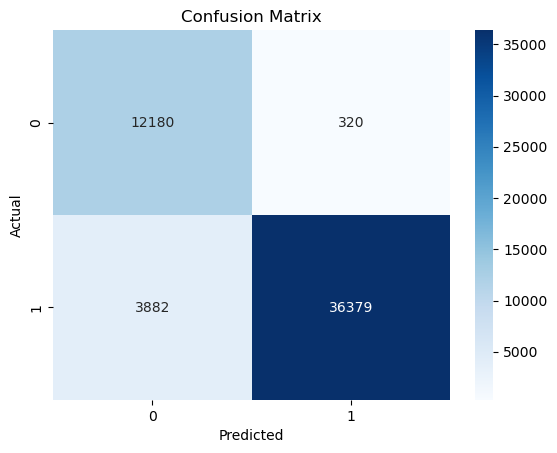

In [33]:

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Comparison to last model
Compared to the old model, the new categorical model performs better overall. Accuracy increased from 0.85 to 0.92, and weighted F1-score improved from 0.85 to 0.92, meaning the new model makes fewer overall classification errors. The biggest improvement is in identifying normal traffic: normal recall increased from 0.61 to 0.97, so the new model produces far fewer false alarms. Normal F1 also improved from 0.66 to 0.85. However, attack recall decreased slightly from 0.93 to 0.90, meaning the new model catches slightly fewer attacks than the old model. This creates an important tradeoff: the new model is much better balanced and more reliable overall, but the old model was slightly more aggressive at flagging attacks. The next area to work on is improving attack recall in the new model without losing too much of its stronger normal-traffic performance.